# Camada Gold: Metricas de Negocio

In [0]:

%run ./00_Pipeline_Football_Setup

# Setup Inicial do Ambiente
## Arquitetura Agnóstica (Cloud vs Local)

Este projeto foi construído para ser **100% agnóstico de infraestrutura**. Isso significa que a mesma regra de negócio desenvolvida em PySpark pode ser executada sem nenhuma alteração em:

1. **Nuvem Corporativa (Ex: Databricks, AWS e Azure):** Usando o Unity Catalog, Glue.
2. **Ambiente Local (Docker / Jupyter):** Salvando os arquivos localmente usando o formato aberto Delta Lake (`.save()`).

A variável `ENVIRONMENT` controla essa chave de forma transparente para as camadas Bronze, Silver e Gold. Altere-a dependendo da sua stack.

Ambiente configurado: databricks


In [0]:
if ENVIRONMENT == "databricks":
    df_eventos_gol = spark.table(f"{CATALOG_SILVER}.goal_events")
else:
    df_eventos_gol = spark.read.format("delta").load(f"{PATH_SILVER}/goal_events")

print(f"Total de eventos analisados: {df_eventos_gol.count()}")

Total de eventos analisados: 1195


In [0]:
# 1. PREPARANDO A BASE DE GOLS
# Selecionamos apenas as colunas essenciais da camada Silver para as nossas contas.
df_base = df_eventos_gol.select(
    "match_id", "competition_name", "match_date",
    "home_team", "away_team", "home_score_ft", "away_score_ft",
    "scorer", F.col("minute").alias("goal_minute"), "event_seq",
    "is_penalty", "is_own_goal", "credited_team", "conceding_team"
)

In [0]:
# 2. OLHANDO PARA O PASSADO (Quantos gols o time tinha antes desse gol?)
# Criamos alias da nossa tabela para poder cruzar a tabela com ela mesma (Self-Join)
base_original = df_base.alias("base_original")
base_pesquisa = df_base.alias("base_pesquisa")

# Condicao: Pegar gols da mesma partida que aconteceram em um minuto ANTERIOR ao gol atual
condicao_gols_anteriores = (
    (F.col("base_pesquisa.match_id") == F.col("base_original.match_id"))
    & ((F.col("base_pesquisa.goal_minute") < F.col("base_original.goal_minute"))
       | ((F.col("base_pesquisa.goal_minute") == F.col("base_original.goal_minute"))
          & (F.col("base_pesquisa.event_seq") < F.col("base_original.event_seq"))))
)

# Quantos gols o Mandante (Home) tinha?
df_gols_mandante_antes = (base_original.join(base_pesquisa.filter(F.col("base_pesquisa.credited_team") == F.col("base_pesquisa.home_team")), condicao_gols_anteriores, "left")
    .groupBy(F.col("base_original.match_id"), F.col("base_original.goal_minute"), F.col("base_original.event_seq"))
    .agg(F.count(F.col("base_pesquisa.match_id")).alias("home_goals_before")))

# Quantos gols o Visitante (Away) tinha?
df_gols_visitante_antes = (base_original.join(base_pesquisa.filter(F.col("base_pesquisa.credited_team") == F.col("base_pesquisa.away_team")), condicao_gols_anteriores, "left")
    .groupBy(F.col("base_original.match_id"), F.col("base_original.goal_minute"), F.col("base_original.event_seq"))
    .agg(F.count(F.col("base_pesquisa.match_id")).alias("away_goals_before")))

In [0]:
# 3. OLHANDO PARA O FUTURO (O time reagiu e fez gols depois disso?)
base_apos = df_base.alias("base_apos")

# Condicao: Pegar gols da mesma partida que aconteceram em um minuto POSTERIOR ao gol atual
# IMPORTANTE: Apenas gols marcados pelo time que SOFREU (conceding_team) o gol atual
condicao_gols_posteriores = (
    (F.col("base_apos.match_id") == F.col("base_original.match_id"))
    & (F.col("base_apos.credited_team") == F.col("base_original.conceding_team"))
    & ((F.col("base_apos.goal_minute") > F.col("base_original.goal_minute"))
       | ((F.col("base_apos.goal_minute") == F.col("base_original.goal_minute"))
          & (F.col("base_apos.event_seq") > F.col("base_original.event_seq"))))
)

df_gols_marcados_apos_sofrer = (base_original.join(base_apos, condicao_gols_posteriores, "left")
    .groupBy(F.col("base_original.match_id"), F.col("base_original.goal_minute"), F.col("base_original.event_seq"))
    .agg(F.count(F.col("base_apos.match_id")).alias("goals_scored_after_conceding")))

In [0]:
# 4. JUNTANDO PASSADO E FUTURO NA MESMA TABELA
# Pegamos a base original e grudamos (join) as contagens de passado e futuro que calculamos acima
df_completo = (
    df_base
    .join(df_gols_mandante_antes, ["match_id", "goal_minute", "event_seq"], "left")
    .join(df_gols_visitante_antes, ["match_id", "goal_minute", "event_seq"], "left")
    .join(df_gols_marcados_apos_sofrer, ["match_id", "goal_minute", "event_seq"], "left")
    .fillna(0, subset=["home_goals_before", "away_goals_before", "goals_scored_after_conceding"])
)

In [0]:
# 5. REGRAS FINAIS E FLAGS (Reagiu? Ganhou? Perdeu?)
df_resposta_apos_sofrer_gol = (
    df_completo
    .withColumn("scoring_team", F.col("credited_team"))
    .withColumn("score_diff_before_goal",
        F.when(F.col("conceding_team") == F.col("home_team"),
            F.col("home_goals_before") - F.col("away_goals_before"))
        .otherwise(F.col("away_goals_before") - F.col("home_goals_before")))
    
    # Descobrindo o resultado final da partida na otica do time que SOFREU o gol
    .withColumn("final_result",
        F.when((F.col("conceding_team") == F.col("home_team")) & (F.col("home_score_ft") > F.col("away_score_ft")), "WIN")
        .when((F.col("conceding_team") == F.col("home_team")) & (F.col("home_score_ft") == F.col("away_score_ft")), "DRAW")
        .when((F.col("conceding_team") == F.col("home_team")) & (F.col("home_score_ft") < F.col("away_score_ft")), "LOSS")
        .when((F.col("conceding_team") == F.col("away_team")) & (F.col("away_score_ft") > F.col("home_score_ft")), "WIN")
        .when((F.col("conceding_team") == F.col("away_team")) & (F.col("away_score_ft") == F.col("home_score_ft")), "DRAW")
        .when((F.col("conceding_team") == F.col("away_team")) & (F.col("away_score_ft") < F.col("home_score_ft")), "LOSS")
        .otherwise("UNKNOWN"))
        
    # Flag principal: Se ele fez mais de 0 gols apos sofrer o gol, quer dizer que ele REAGIU!
    .withColumn("reacted_flag", F.when(F.col("goals_scored_after_conceding") > 0, 1).otherwise(0))
    .withColumn("built_at", F.current_timestamp())
    .select(
        "match_id", "competition_name", "match_date",
        "home_team", "away_team",
        "conceding_team", "scoring_team", "scorer",
        "goal_minute", "event_seq", "is_penalty", "is_own_goal",
        "score_diff_before_goal", "goals_scored_after_conceding",
        "final_result", "reacted_flag", "built_at"
    )
)

print("Regra de negocio calculada com sucesso!")

Regra de negocio calculada com sucesso!


In [0]:
df_resumo_competicao = (
    df_resposta_apos_sofrer_gol
    .groupBy("competition_name")
    .agg(
        F.count("*").alias("conceded_events"),
        F.sum("reacted_flag").alias("reacted_events"),
        F.round(100.0 * F.sum("reacted_flag") / F.count("*"), 2).alias("pct_reacted"),
        F.round(F.avg("goals_scored_after_conceding"), 3).alias("avg_goals_after_conceding"),
        F.sum(F.when(F.col("final_result") == "WIN", 1).otherwise(0)).alias("events_ended_win"),
        F.sum(F.when(F.col("final_result") == "DRAW", 1).otherwise(0)).alias("events_ended_draw"),
        F.sum(F.when(F.col("final_result") == "LOSS", 1).otherwise(0)).alias("events_ended_loss"),
        F.round(100.0 * F.sum(F.when(F.col("final_result") == "WIN", 1).otherwise(0)) / F.count("*"), 2).alias("pct_ended_win"),
    )
    .withColumn("built_at", F.current_timestamp())
    .orderBy("competition_name")
)

In [0]:
# Gerando os dados da camada GOLD

# Fato: fact_reaction_events -> Tabela com a granularidade no nível do evento (gol a gol) e a flag binária de reação.
# Dimensão: dim_competition_summary -> Tabela consolidada com os KPIs agregados por edição da Copa do Mundo.

tabelas_gold = {
    "fact_reaction_events": df_resposta_apos_sofrer_gol,
    "dim_competition_summary": df_resumo_competicao,
}

for nome, df in tabelas_gold.items():
    if ENVIRONMENT == "databricks":
        df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").saveAsTable(f"{CATALOG_GOLD}.{nome}")
    else:
        df.write.format("delta").mode("overwrite").option("overwriteSchema", "true").save(f"{PATH_GOLD}/{nome}")

print("Tabelas da Camada Gold (Fato e Dimensão) criadas com sucesso.")

Tabelas da Camada Gold (Fato e Dimensão) criadas com sucesso.


In [0]:
%sql

select * from workspace.gold.dim_competition_summary
limit 5

competition_name,conceded_events,reacted_events,pct_reacted,avg_goals_after_conceding,events_ended_win,events_ended_draw,events_ended_loss,pct_ended_win,built_at
World Cup 1930,70,29,41.43,0.714,11,0,59,15.71,2026-07-19T15:02:56.582Z
World Cup 1934,70,42,60.0,1.0,18,10,42,25.71,2026-07-19T15:02:56.582Z
World Cup 1938,84,38,45.24,1.0,12,27,45,14.29,2026-07-19T15:02:56.582Z
World Cup 1950,88,42,47.73,0.693,13,12,63,14.77,2026-07-19T15:02:56.582Z
World Cup 1990,8,4,50.0,0.5,1,4,3,12.5,2026-07-19T15:02:56.582Z


In [0]:
%sql
select * from workspace.gold.fact_reaction_events
limit 5

match_id,competition_name,match_date,home_team,away_team,conceding_team,scoring_team,scorer,goal_minute,event_seq,is_penalty,is_own_goal,score_diff_before_goal,goals_scored_after_conceding,final_result,reacted_flag,built_at
0030aa35f001c27af1361f0158af3590,World Cup 2018,2018-07-07,Sweden,England,Sweden,England,Harry Maguire,30,1,0,0,0,0,LOSS,0,2026-07-19T15:02:53.231Z
0030aa35f001c27af1361f0158af3590,World Cup 2018,2018-07-07,Sweden,England,Sweden,England,Dele Alli,58,2,0,0,-1,0,LOSS,0,2026-07-19T15:02:53.231Z
0040274278df02c89b2689b49bcc3bfa,World Cup 2018,2018-07-06,Uruguay,France,Uruguay,France,Raphaël Varane,40,1,0,0,0,0,LOSS,0,2026-07-19T15:02:53.231Z
0040274278df02c89b2689b49bcc3bfa,World Cup 2018,2018-07-06,Uruguay,France,Uruguay,France,Antoine Griezmann,61,2,0,0,-1,0,LOSS,0,2026-07-19T15:02:53.231Z
00bec281fafc7d47075d14d419616860,World Cup 1930,1930-07-17,Yugoslavia,Bolivia,Bolivia,Yugoslavia,Bek,60,1,0,0,0,0,LOSS,0,2026-07-19T15:02:53.231Z


In [0]:

# A CONSULTA FINAL DE NEGÓCIO


# Aqui respondemos à pergunta final do nosso trabalho:
# "Qual % das seleções reage após sofrer um gol, e como isso evoluiu entre as edições da Copa?"

# Fazendo o SELECT final ordenado pela edição da Copa para ver a evolução temporal
df_resposta_final = (
    df_resumo_competicao
    .select(
        "competition_name",
        "conceded_events",
        "reacted_events",
        "pct_reacted",
        "pct_ended_win"
    )
    .orderBy("competition_name")
)
df_resposta_final.show(50, truncate=False)


+-------------------------+---------------+--------------+-----------+-------------+
|competition_name         |conceded_events|reacted_events|pct_reacted|pct_ended_win|
+-------------------------+---------------+--------------+-----------+-------------+
|World Cup 1930           |70             |29            |41.43      |15.71        |
|World Cup 1934           |70             |42            |60.0       |25.71        |
|World Cup 1938           |84             |38            |45.24      |14.29        |
|World Cup 1950           |88             |42            |47.73      |14.77        |
|World Cup 1990           |8              |4             |50.0       |12.5         |
|World Cup 2006           |9              |4             |44.44      |11.11        |
|World Cup 2014           |171            |75            |43.86      |17.54        |
|World Cup 2018           |169            |75            |44.38      |14.2         |
|World Cup 2022           |172            |75            |43.6   

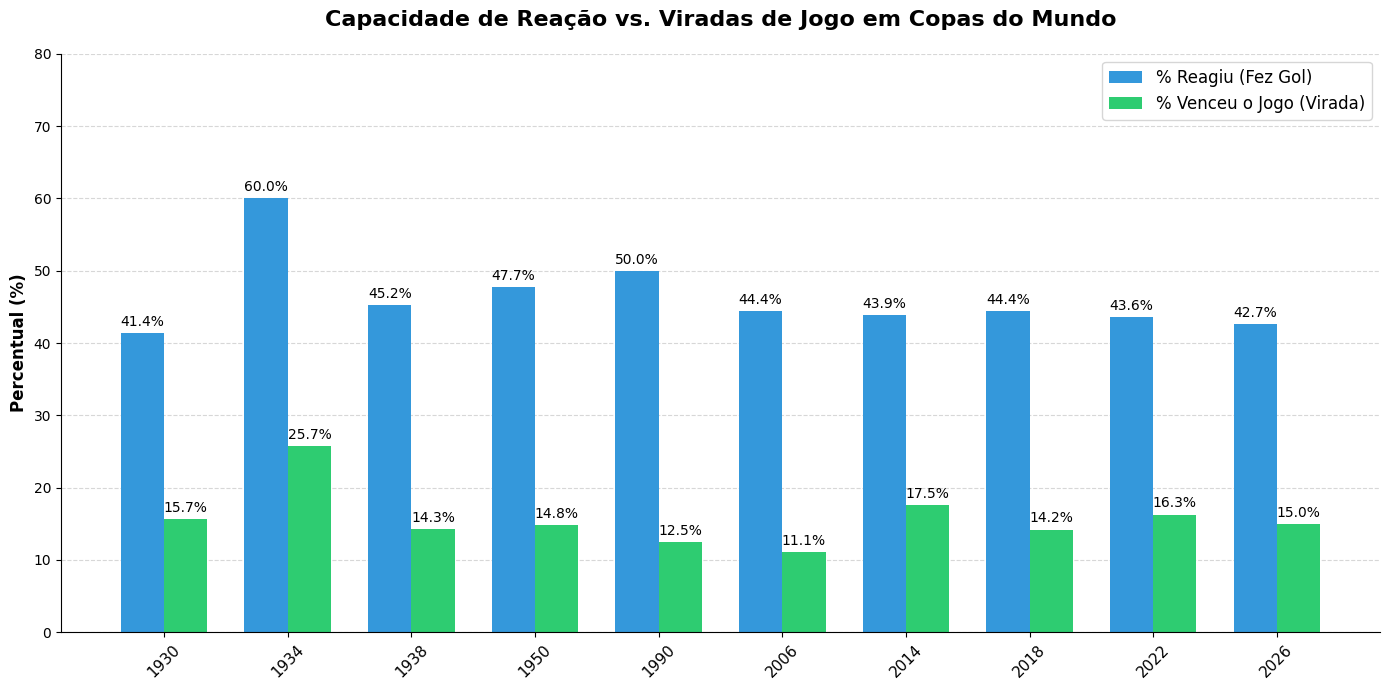

In [0]:
#Dashboard

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Preparação dos dados
pdf_plot = df_resposta_final.toPandas()
pdf_plot = pdf_plot[~pdf_plot['competition_name'].str.contains('Qualifying')]
pdf_plot['year'] = pdf_plot['competition_name'].str.extract(r'(\d{4})').astype(int)

labels = pdf_plot['year'].astype(str)
reacted = pdf_plot['pct_reacted']
won = pdf_plot['pct_ended_win']

# Configuração das posições das barras
x = np.arange(len(labels))
width = 0.35 

# Criando a figura/tamanho
fig, ax = plt.subplots(figsize=(14, 7))

# Plotando as barras lado a lado (Cores modernas: Azul e Verde)
rects1 = ax.bar(x - width/2, reacted, width, label='% Reagiu (Fez Gol)', color='#3498db')
rects2 = ax.bar(x + width/2, won, width, label='% Venceu o Jogo (Virada)', color='#2ecc71')

# Customização dos Textos e Eixos
ax.set_ylabel('Percentual (%)', fontsize=12, fontweight='bold')
ax.set_title('Capacidade de Reação vs. Viradas de Jogo em Copas do Mundo', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, fontsize=11)
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim(0, 80) 

# Colocando os números exatos em cima de cada barra
ax.bar_label(rects1, padding=3, fmt='%.1f%%', fontsize=10)
ax.bar_label(rects2, padding=3, fmt='%.1f%%', fontsize=10)

# Deixando o fundo mais claro
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()